In [1]:
# imports
import os, glob, math
from collections import deque
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import load_model
plt.rcParams['figure.figsize'] = (12,5)
print("TF", tf.__version__)


TF 2.20.0


In [2]:
# Data is in Drive, mount it.
from google.colab import drive
drive.mount('/content/drive')

# Set base folder where your dataset is.
BASE_DIR = '/content/drive/MyDrive/major_data'
os.makedirs(BASE_DIR, exist_ok=True)
print("BASE_DIR:", BASE_DIR)

Mounted at /content/drive
BASE_DIR: /content/drive/MyDrive/major_data


In [3]:
# Use the cleaned folder path
csv_files = glob.glob("/content/drive/MyDrive/major_data/cleaned/*.csv")
print("CSV files found:", csv_files)

processed_data = {}

for file in csv_files:
    company_name = os.path.splitext(os.path.basename(file))[0]
    df = pd.read_csv(file)

    print(f"{company_name} raw shape: {df.shape}")  # Check if file has rows/columns

    # Only keep if df is not empty
    if df.shape[0] > 0:
        processed_data[company_name] = df

print("Companies loaded:", list(processed_data.keys()))

CSV files found: ['/content/drive/MyDrive/major_data/cleaned/Adani Enterprises Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Adani ports and special Economic.csv', '/content/drive/MyDrive/major_data/cleaned/Bajaj Finance Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Axis Bank Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Bajaj Finserv Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Bharat Electronics Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Bharti Airtel Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Eternal Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/HCL Technologies Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/HDFC Bank Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Hindustan Unilever Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/ICICI Bank Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/ITC Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Infosys Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/JS

In [4]:
# Paths
cleaned_folder = "/content/drive/MyDrive/major_data/cleaned"
csv_files = glob.glob(os.path.join(cleaned_folder, "*.csv"))
print("CSV files found:", csv_files)

# Create output folder
output_folder = "/content/drive/MyDrive/major_data/processed_with_features"
os.makedirs(output_folder, exist_ok=True)

# Processed data dictionary
processed_data = {}

# Loop through CSVs
for file in csv_files:
    company_name = os.path.splitext(os.path.basename(file))[0]
    df = pd.read_csv(file)
    print(f"{company_name} raw shape: {df.shape}")

    # Standardize column names
    df.columns = df.columns.str.strip().str.capitalize()

    # Rename inconsistent columns if needed
    rename_dict = {'Date ': 'Date', 'Close': 'Close', 'Volume': 'Volume'}
    df.rename(columns=rename_dict, inplace=True)

    # Keep only necessary columns
    required_cols = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
    df = df[[col for col in df.columns if col in required_cols]]

    # Convert numeric columns
    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

    # Handle missing data
    df.ffill(inplace=True)
    df.bfill(inplace=True)
    df.dropna(subset=['Open', 'High', 'Low', 'Close', 'Volume'], inplace=True)

    # Convert Date to datetime & sort
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df.dropna(subset=['Date'], inplace=True)
    df = df.sort_values('Date').reset_index(drop=True)

    print(f"{company_name} rows after numeric conversion: {df.shape[0]}")

    # Skip if not enough rows
    if df.shape[0] < 5:  # can adjust threshold based on your feature window
        print(f" Skipping {company_name}, not enough rows")
        continue


    # Feature creation for LSTM
    df['Return'] = df['Close'].pct_change()
    df['High_Low'] = (df['High'] - df['Low']) / df['Low']
    df['Open_Close'] = (df['Open'] - df['Close']) / df['Close']
    df['Volume_Change'] = df['Volume'].pct_change()

    # Drop first row which has NaN from pct_change
    df.dropna(inplace=True)

    # Save processed data
    processed_data[company_name] = df
    print(f" Features created for {company_name}: {df.shape}")

    output_file_path = os.path.join(output_folder, f"{company_name}_features.csv")
    df.to_csv(output_file_path, index=False)
    print(f"Saved processed file with features: {output_file_path}")

# Summary
print("Companies ready:", list(processed_data.keys()))

CSV files found: ['/content/drive/MyDrive/major_data/cleaned/Adani Enterprises Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Adani ports and special Economic.csv', '/content/drive/MyDrive/major_data/cleaned/Bajaj Finance Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Axis Bank Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Bajaj Finserv Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Bharat Electronics Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Bharti Airtel Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Eternal Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/HCL Technologies Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/HDFC Bank Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Hindustan Unilever Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/ICICI Bank Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/ITC Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/Infosys Ltd.csv', '/content/drive/MyDrive/major_data/cleaned/JS

In [ ]:
# Again adding new features to increase accuracy(LSTM MODEL 3 starts)

In [5]:
import os

# Folders to save Model3 models, history, plots, and metrics
LSTM_3 = "/content/drive/MyDrive/major_data/LSTM_3"
os.makedirs(LSTM_3, exist_ok=True)

MODEL_DIR3 = "/content/drive/MyDrive/major_data/LSTM_3/lstm_saved_model3"
os.makedirs(MODEL_DIR3, exist_ok=True)

HIST_DIR3 = "/content/drive/MyDrive/major_data/LSTM_3/lstm3_history"
os.makedirs(HIST_DIR3, exist_ok=True)

PLOT_DIR3 = "/content/drive/MyDrive/major_data/LSTM_3/lstm3_plots"
os.makedirs(PLOT_DIR3, exist_ok=True)

METRICS_DIR3 = "/content/drive/MyDrive/major_data/LSTM_3/lstm3_metrics"
os.makedirs(METRICS_DIR3, exist_ok=True)


In [6]:
# Parameters
timesteps = 10
n_epochs = 100
batch_size = 32

In [7]:
MODEL_TAG = "lstm_model3"

# Feature Engineering Functions
def compute_RSI(series, window=14):
    delta = series.diff()
    gain = np.where(delta > 0, delta, 0)
    loss = np.where(delta < 0, -delta, 0)
    avg_gain = pd.Series(gain).rolling(window=window, min_periods=1).mean()
    avg_loss = pd.Series(loss).rolling(window=window, min_periods=1).mean()
    rs = avg_gain / (avg_loss + 1e-10)
    rsi = 100 - (100 / (1 + rs))
    return rsi

def compute_MACD(series, fast=12, slow=26):
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    return macd

def create_features(df):
    df = df.copy()
    for lag in range(1, 6):
        df[f'Close_lag{lag}'] = df['Close'].shift(lag)
        df[f'Volume_lag{lag}'] = df['Volume'].shift(lag)
    df['Close_roll_mean_5'] = df['Close'].rolling(5).mean()
    df['Close_roll_std_5'] = df['Close'].rolling(5).std()
    df['Close_roll_max_5'] = df['Close'].rolling(5).max()
    df['Close_roll_min_5'] = df['Close'].rolling(5).min()
    df['SMA_10'] = df['Close'].rolling(10).mean()
    df['EMA_10'] = df['Close'].ewm(span=10, adjust=False).mean()
    df['RSI_14'] = compute_RSI(df['Close'], window=14)
    df['MACD'] = compute_MACD(df['Close'])
    df['High_Low'] = df['High'] - df['Low']
    df['Close_Open'] = df['Close'] - df['Open']
    df['Momentum_5'] = df['Close'] - df['Close'].shift(5)
    df['Return'] = df['Close'].pct_change()
    df = df.dropna().reset_index(drop=True)
    return df

# --- Sequence creation ---
def create_sequences(X, y, timesteps):
    X_seq, y_seq = [], []
    for i in range(timesteps, len(X)):
        X_seq.append(X[i-timesteps:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

# --- Dictionary to store models ---
all_lstm_models = {}

In [8]:
import pickle
for company, df in processed_data.items():
    print(f"Processing {company}...")

    df_feat = create_features(df)
    feature_columns = [col for col in df_feat.columns if col not in ['Date', 'Close']]

    # Train/Val/Test split
    n = len(df_feat)
    train_size = int(n*0.7)
    val_size = int(n*0.15)
    train_df = df_feat.iloc[:train_size]
    val_df   = df_feat.iloc[train_size:train_size+val_size]
    test_df  = df_feat.iloc[train_size+val_size:]

    # Scaling
    feature_scaler = MinMaxScaler()
    X_train_scaled = feature_scaler.fit_transform(train_df[feature_columns])
    X_val_scaled   = feature_scaler.transform(val_df[feature_columns])
    X_test_scaled  = feature_scaler.transform(test_df[feature_columns])

    target_scaler = MinMaxScaler()
    y_train_scaled = target_scaler.fit_transform(train_df[['Close']])
    y_val_scaled   = target_scaler.transform(val_df[['Close']])
    y_test_scaled  = target_scaler.transform(test_df[['Close']])

    # Create sequences
    X_train, y_train = create_sequences(X_train_scaled, y_train_scaled, timesteps)
    X_val, y_val     = create_sequences(X_val_scaled, y_val_scaled, timesteps)
    X_test, y_test   = create_sequences(X_test_scaled, y_test_scaled, timesteps)

    # Save data in dict first
    all_lstm_models[company] = {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test,
        'feature_scaler': feature_scaler,
        'target_scaler': target_scaler,
        'timesteps': timesteps,
        'feature_columns': feature_columns,
        'type' : 'lstm_model3'
    }

    # Build LSTM Model
    model3 = Sequential([
        LSTM(128, return_sequences=True, input_shape=(timesteps, len(feature_columns))),
        Dropout(0.3),
        LSTM(64),
        Dropout(0.2),
        Dense(1)
    ])
    model3.compile(optimizer='adam', loss='mse')

    early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

    # Train model
    history3 = model3.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=n_epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1
    )

    # Save model & history in the dict
    all_lstm_models[company]['model3'] = model3
    all_lstm_models[company]['history3'] = history3.history

    # Save history for later plotting
    company_safe = company.replace(" ", "_").replace(".", "")
    history_file = os.path.join(HIST_DIR3, f"{company_safe}_history3.pkl")
    with open(history_file, "wb") as f:
        pickle.dump(history3.history, f)  #  use history3.history

    print(f" LSTM Model3 trained and saved for {company}")


Processing Adani Enterprises Ltd...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.0057 - val_loss: 0.0061
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0012 - val_loss: 0.0034
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011 - val_loss: 0.0036
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011 - val_loss: 0.0035
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.3147e-04 - val_loss: 0.0032
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.4946e-04 - val_loss: 0.0045
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.6404e-04 - val_loss: 0.0032
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.5342e-04 - val_loss: 0.0026
Epoch 9/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.3387e-04 - val_loss: 0.0029
Epoch 10/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.2578e-04 - val_loss: 0.0026
Epoch 11/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.8000e-04 - val_loss: 0.0040
Epoch 12/100
60/60 ━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0109 - val_loss: 1.7589e-04
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0024 - val_loss: 3.3575e-05
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0021 - val_loss: 2.4191e-05
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0021 - val_loss: 3.5166e-05
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0019 - val_loss: 2.5703e-05
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0019 - val_loss: 1.9182e-04
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0013 - val_loss: 8.3265e-05
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0014 - val_loss: 2.1384e-04
Epoch 9/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0015 - val_loss: 2.8330e-05
Epoch 10/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0013 - val_loss: 5.3446e-05
 LSTM Model3 trained and saved for Adani ports and special Economic
Processing Bajaj Finance Ltd...
Epoch 1/100


...

60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0092 - val_loss: 0.0114
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0023 - val_loss: 0.0027
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0025 - val_loss: 0.0026
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0018 - val_loss: 0.0093
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0018 - val_loss: 0.0122
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0016 - val_loss: 0.0020
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0017 - val_loss: 0.0017
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0014 - val_loss: 0.0059
Epoch 9/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0015 - val_loss: 0.0065
Epoch 10/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0014 - val_loss: 0.0015
Epoch 11/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0012 - val_loss: 0.0051
Epoch 12/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0013 -

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0101 - val_loss: 0.0212
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0025 - val_loss: 0.0104
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0025 - val_loss: 0.0033
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0022 - val_loss: 0.0042
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0018 - val_loss: 0.0027
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0019 - val_loss: 0.0029
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0020 - val_loss: 0.0119
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0016 - val_loss: 0.0152
Epoch 9/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0020 - val_loss: 0.0035
Epoch 10/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0018 - val_loss: 0.0058
Epoch 11/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0015 - val_loss: 0.0031
Epoch 12/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0017 - 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0137 - val_loss: 6.6735e-04
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0037 - val_loss: 0.0022
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0033 - val_loss: 8.2651e-04
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0031 - val_loss: 0.0014
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0029 - val_loss: 0.0011
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0028 - val_loss: 8.5984e-04
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0029 - val_loss: 3.8950e-04
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0024 - val_loss: 4.0872e-04
Epoch 9/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0025 - val_loss: 0.0030
Epoch 10/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0022 - val_loss: 6.2067e-04
Epoch 11/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0022 - val_loss: 0.0015
Epoch 12/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms

In [9]:
import joblib, json
for company, data in all_lstm_models.items():

    if 'model3' not in data:
        print(f"Skipping {company} — Model3 not found")
        continue

    safe_name = company.replace(" ", "_").replace(".", "")
    company_dir = os.path.join(MODEL_DIR3, safe_name)
    os.makedirs(company_dir, exist_ok=True)

    # Save LSTM Model3
    model_path = os.path.join(company_dir, "lstm_model3.keras")
    data['model3'].save(model_path)

    # Save scalers
    joblib.dump(data['feature_scaler'], os.path.join(company_dir, "feature_scaler.pkl"))
    joblib.dump(data['target_scaler'], os.path.join(company_dir, "target_scaler.pkl"))

    # Save metadata
    metadata = {
        "timesteps": data['timesteps'],
        "feature_columns": data['feature_columns']
    }

    with open(os.path.join(company_dir, "metadata.json"), "w") as f:
        json.dump(metadata, f, indent=4)

    print(f"Saved Model3 & scalers for {company}")


Saved Model3 & scalers for Adani Enterprises Ltd
Saved Model3 & scalers for Adani ports and special Economic
Saved Model3 & scalers for Bajaj Finance Ltd
Saved Model3 & scalers for Axis Bank Ltd
Saved Model3 & scalers for Bajaj Finserv Ltd
Saved Model3 & scalers for Bharat Electronics Ltd
Saved Model3 & scalers for Bharti Airtel Ltd
Saved Model3 & scalers for Eternal Ltd
Saved Model3 & scalers for HCL Technologies Ltd
Saved Model3 & scalers for HDFC Bank Ltd
Saved Model3 & scalers for Hindustan Unilever Ltd
Saved Model3 & scalers for ICICI Bank Ltd
Saved Model3 & scalers for ITC Ltd
Saved Model3 & scalers for Infosys Ltd
Saved Model3 & scalers for JSW Steel Ltd
Saved Model3 & scalers for Larsen and Toubro Ltd
Saved Model3 & scalers for Kotak Mahindra Bank Ltd
Saved Model3 & scalers for Mahindra and Mahindra Ltd
Saved Model3 & scalers for Maruti Suzuki India Ltd
Saved Model3 & scalers for NTPC Ltd
Saved Model3 & scalers for Oil and Natural Gas Corporation Ltd
Saved Model3 & scalers for 

In [10]:
for company, data in all_lstm_models.items():

    safe_name = company.replace(" ", "_").replace(".", "")
    history = data['history3']   # Already dictionary

    # Plot training history
    plt.figure(figsize=(8,5))
    plt.plot(history['loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title(f"{company} LSTM Model3 Training History")
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True)

    # Save plot
    plot_path = os.path.join(HIST_DIR3, f"{safe_name}_history3.png")
    plt.savefig(plot_path)
    plt.close()

    print(f" Model3 Training history plot saved for {company}")

 Model3 Training history plot saved for Adani Enterprises Ltd
 Model3 Training history plot saved for Adani ports and special Economic
 Model3 Training history plot saved for Bajaj Finance Ltd
 Model3 Training history plot saved for Axis Bank Ltd
 Model3 Training history plot saved for Bajaj Finserv Ltd
 Model3 Training history plot saved for Bharat Electronics Ltd
 Model3 Training history plot saved for Bharti Airtel Ltd
 Model3 Training history plot saved for Eternal Ltd
 Model3 Training history plot saved for HCL Technologies Ltd
 Model3 Training history plot saved for HDFC Bank Ltd
 Model3 Training history plot saved for Hindustan Unilever Ltd
 Model3 Training history plot saved for ICICI Bank Ltd
 Model3 Training history plot saved for ITC Ltd
 Model3 Training history plot saved for Infosys Ltd
 Model3 Training history plot saved for JSW Steel Ltd
 Model3 Training history plot saved for Larsen and Toubro Ltd
 Model3 Training history plot saved for Kotak Mahindra Bank Ltd
 Model3 T

In [11]:
# EVALUATION
metrics_list = []

for company, data in all_lstm_models.items():
    model = data['model3']
    X_test = data['X_test']
    y_test = data['y_test']
    scaler = data['target_scaler']

    y_pred_scaled = model.predict(X_test)
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_true = scaler.inverse_transform(y_test)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    # Store in master list
    metrics_list.append({
        'Company': company,
        'RMSE': rmse,
        'MAE': mae
    })

    # Save individual company metrics
    company_metrics_df = pd.DataFrame([{
        'Company': company,
        'RMSE': rmse,
        'MAE': mae
    }])

    # Safe filename
    company_safe = company.replace(" ", "_")

    company_metrics_df.to_csv(
        os.path.join(METRICS_DIR3, f"{company_safe}_metrics.csv"),
        index=False
    )

# Save combined metrics
metrics_df = pd.DataFrame(metrics_list)
metrics_df.to_csv(
    os.path.join(METRICS_DIR3, "A_lstm3_test_metrics.csv"),
    index=False
)

print("LSTM Model 3 metrics saved (combined + individual files).")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
LSTM Model 3 metrics saved (combined + i

In [12]:
for company, data in all_lstm_models.items():

    model = data['model3']
    X_test = data['X_test']
    y_test = data['y_test']
    scaler = data['target_scaler']

    y_pred_scaled = model.predict(X_test)

    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_true = scaler.inverse_transform(y_test)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    print(f"{company}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE : {mae:.2f}")
    print("-"*40)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Adani Enterprises Ltd
RMSE: 80.55
MAE : 58.50
----------------------------------------
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Adani ports and special Economic
RMSE: 23.10
MAE : 19.82
----------------------------------------
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Bajaj Finance Ltd
RMSE: 451.19
MAE : 142.83
----------------------------------------
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Axis Bank Ltd
RMSE: 87.99
MAE : 76.86
----------------------------------------
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Bajaj Finserv Ltd
RMSE: 170.38
MAE : 126.96
----------------------------------------
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Bharat Electronics Ltd
RMSE: 15.00
MAE : 12.58
----------------------------------------
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Bharti Airtel Ltd
RMSE: 498.13
MAE : 472.66
----------------------------------------
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Eternal Ltd
RMSE: 26.81
MAE : 20.23
---------------------------------------

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


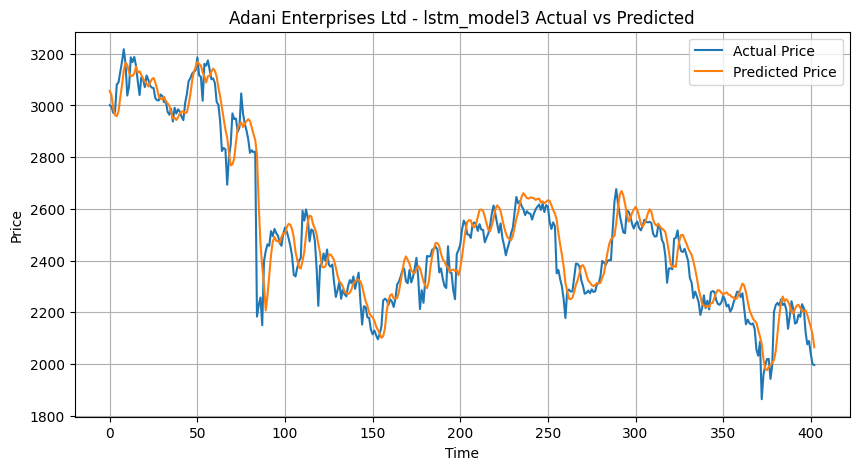

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/Adani_Enterprises_Ltd_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


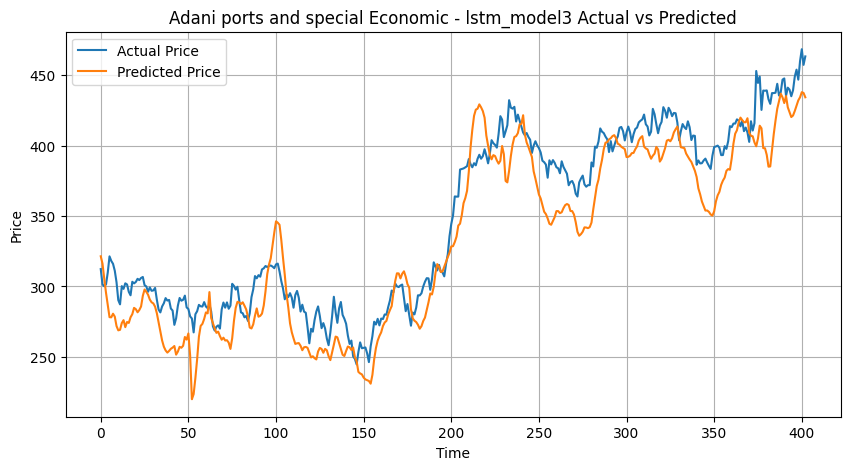

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/Adani_ports_and_special_Economic_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


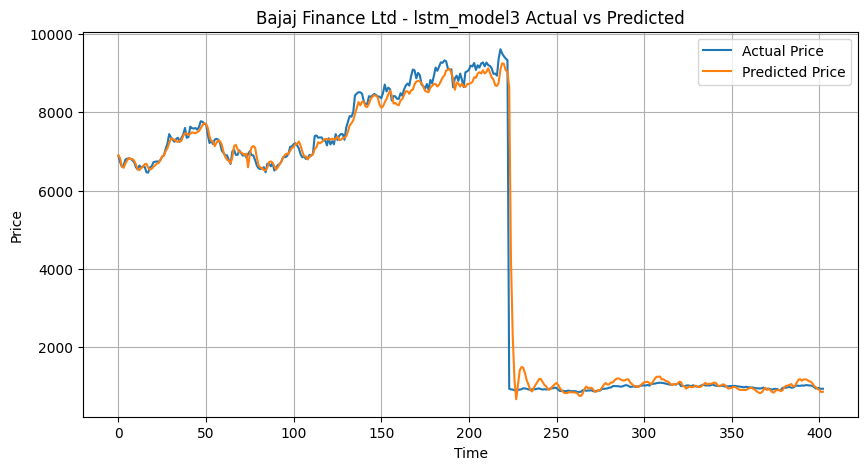

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/Bajaj_Finance_Ltd_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


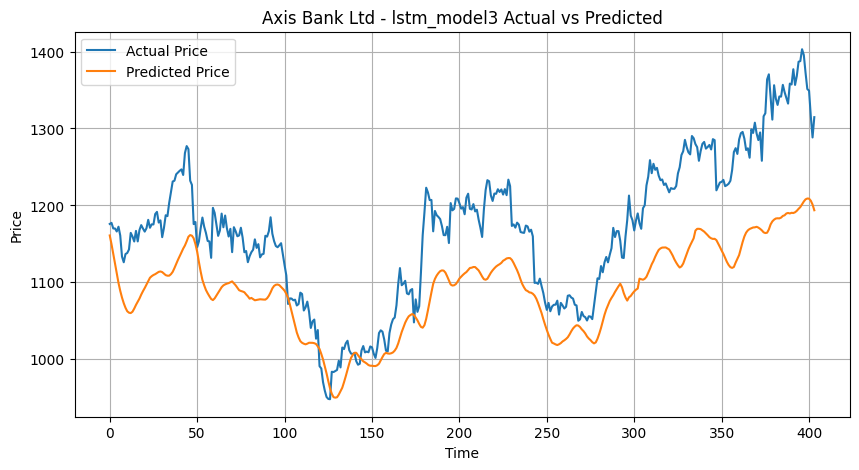

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/Axis_Bank_Ltd_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


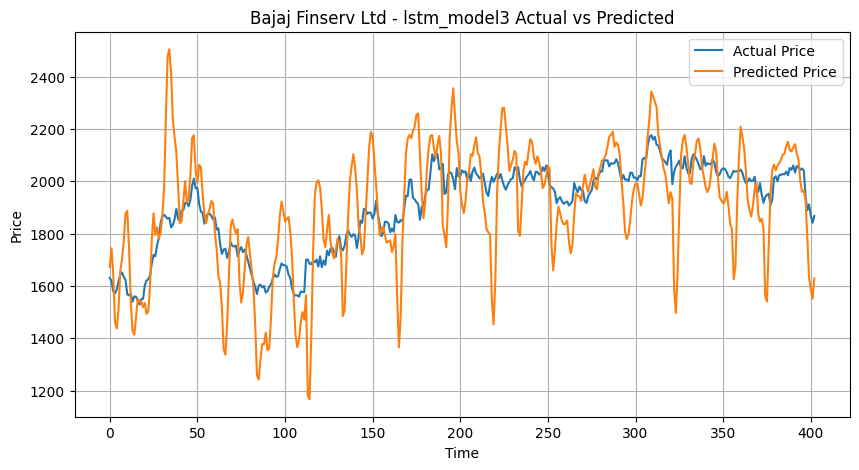

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/Bajaj_Finserv_Ltd_lstm_model3_actual_vs_pred.png
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


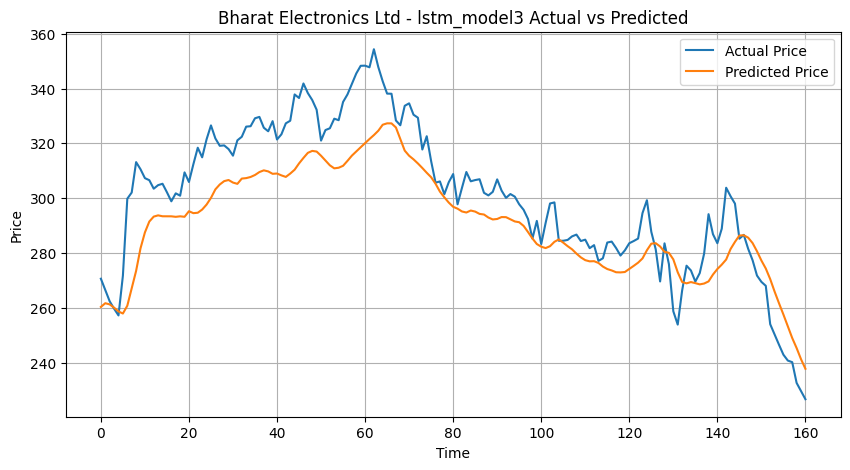

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/Bharat_Electronics_Ltd_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


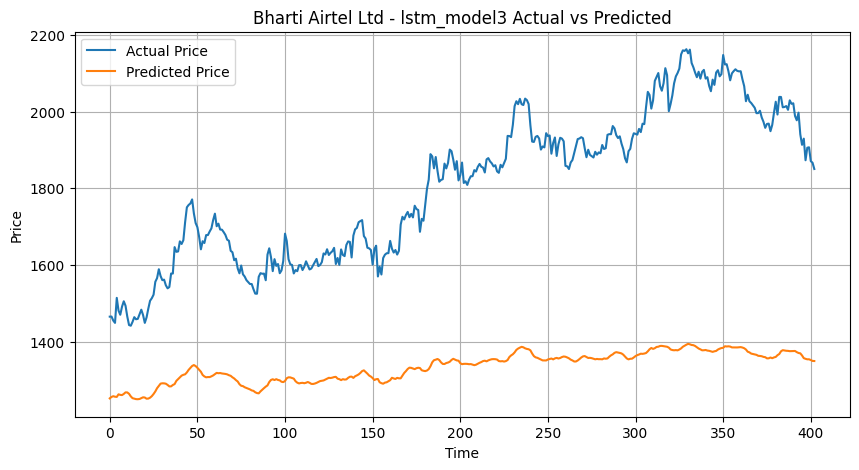

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/Bharti_Airtel_Ltd_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


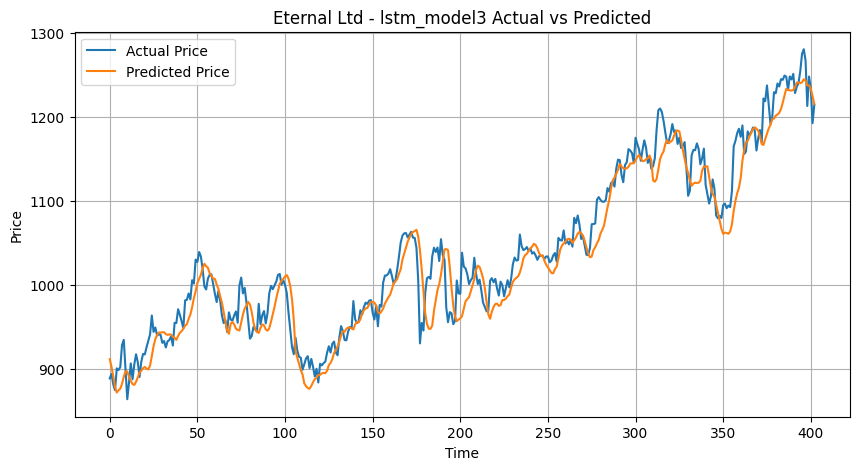

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/Eternal_Ltd_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


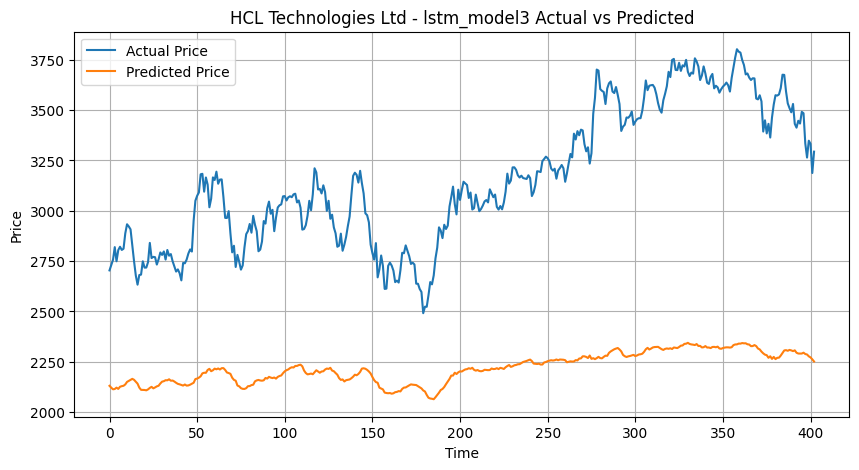

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/HCL_Technologies_Ltd_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


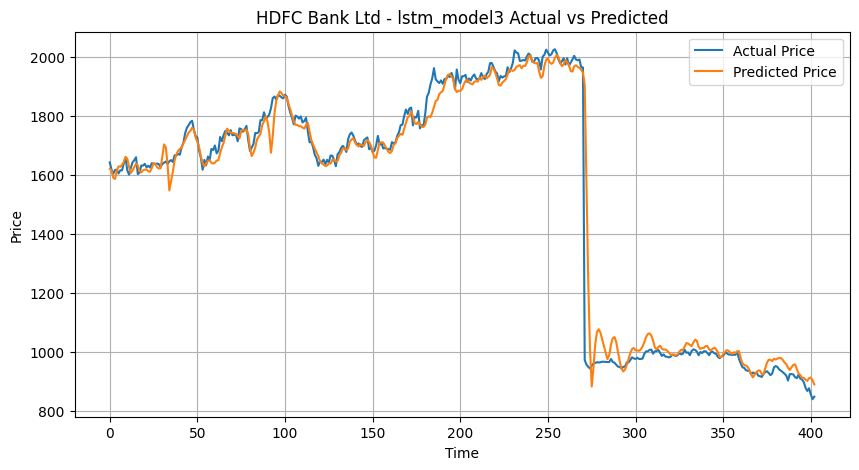

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/HDFC_Bank_Ltd_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


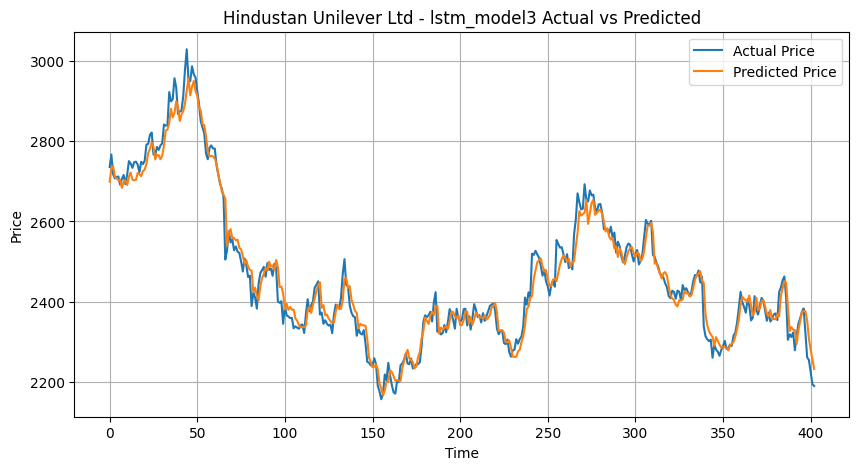

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/Hindustan_Unilever_Ltd_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


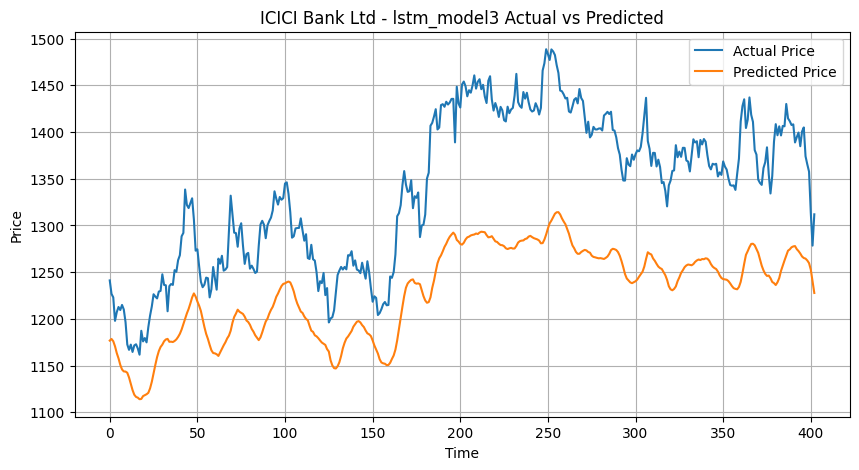

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/ICICI_Bank_Ltd_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


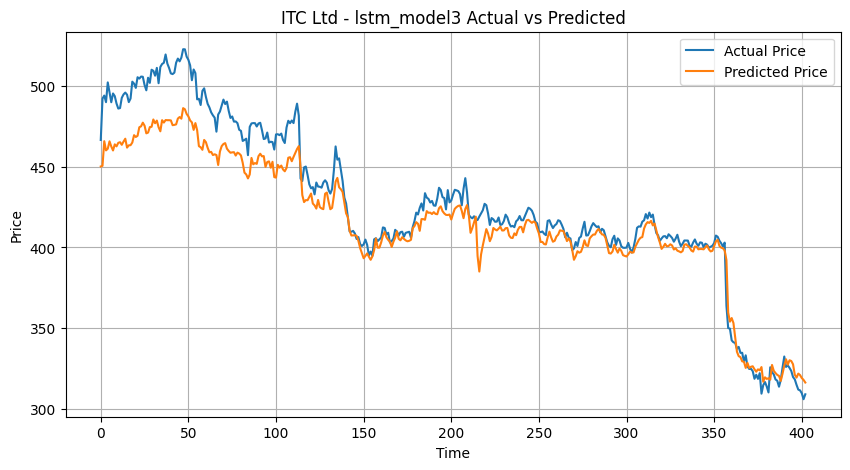

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/ITC_Ltd_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


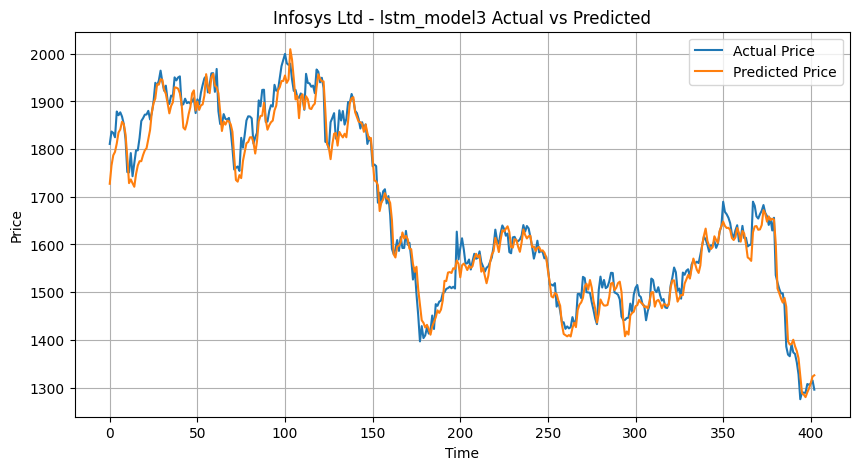

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/Infosys_Ltd_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


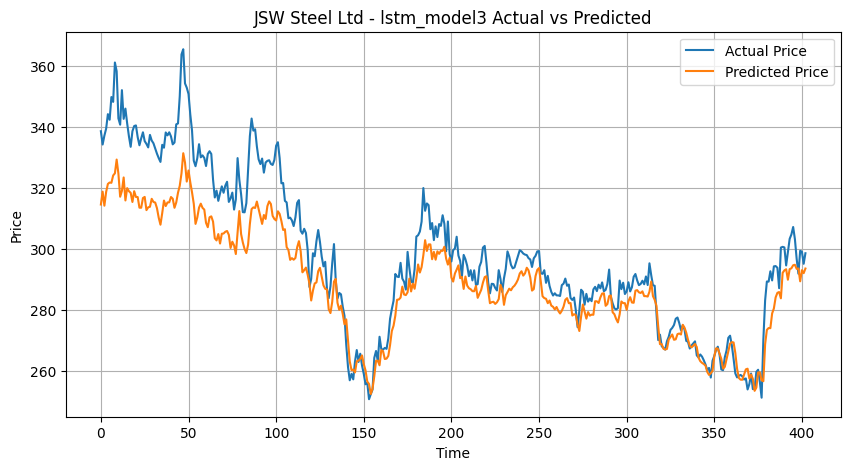

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/JSW_Steel_Ltd_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


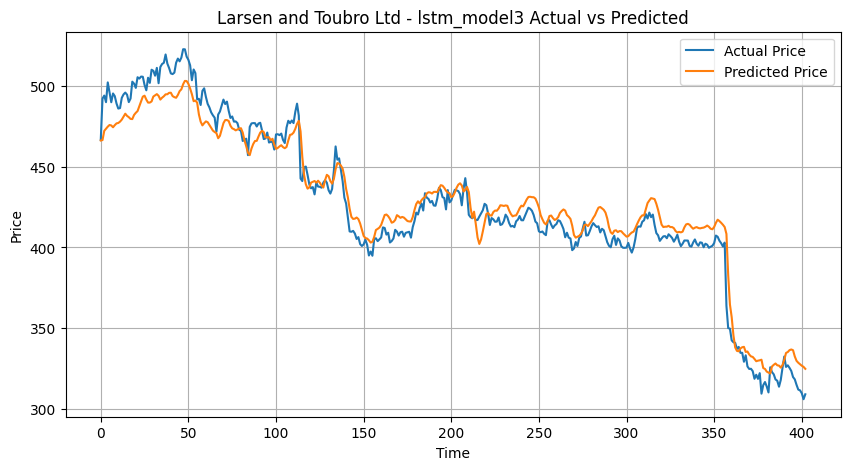

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/Larsen_and_Toubro_Ltd_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


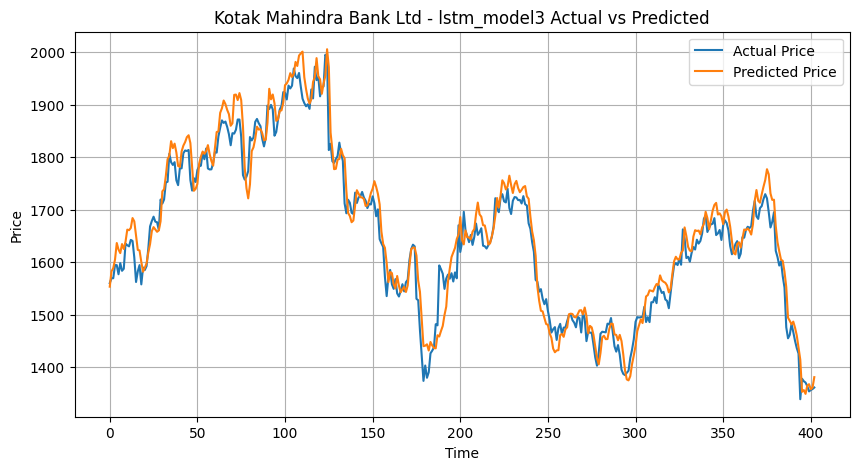

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/Kotak_Mahindra_Bank_Ltd_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


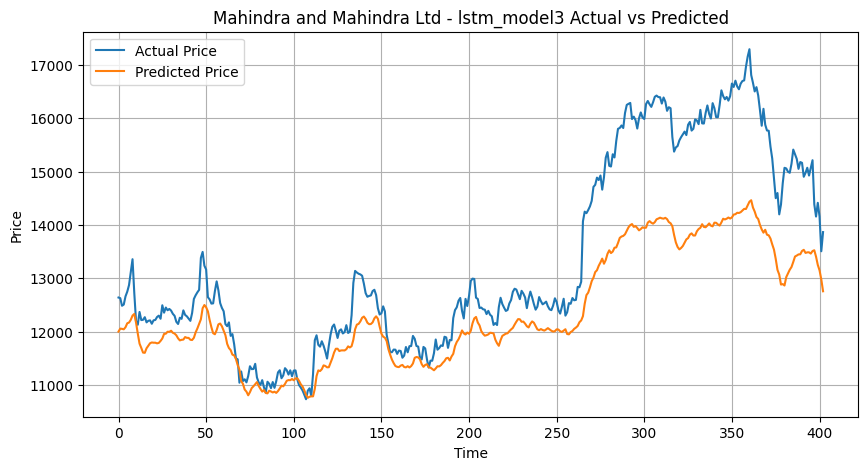

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/Mahindra_and_Mahindra_Ltd_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


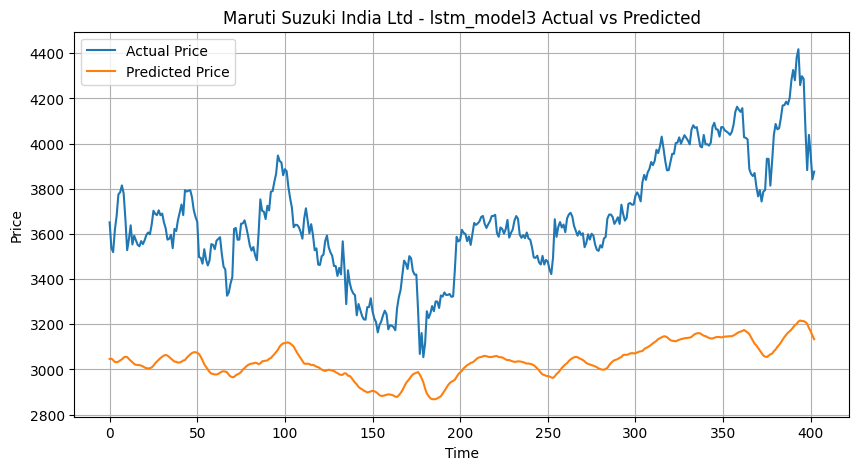

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/Maruti_Suzuki_India_Ltd_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


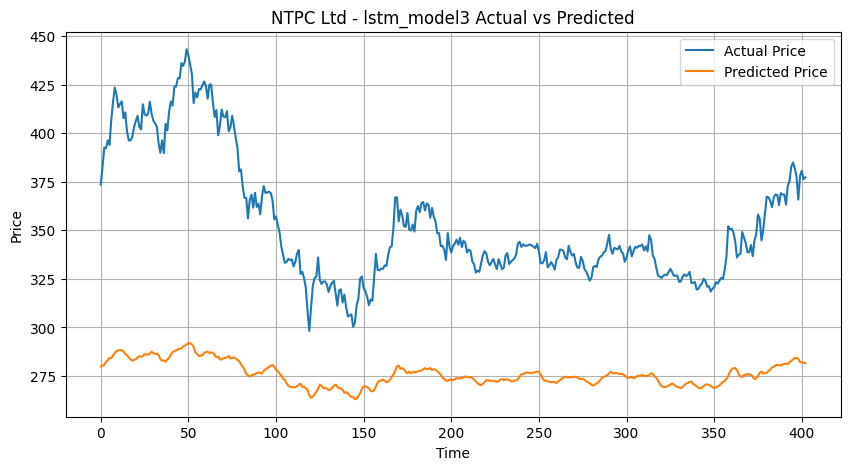

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/NTPC_Ltd_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


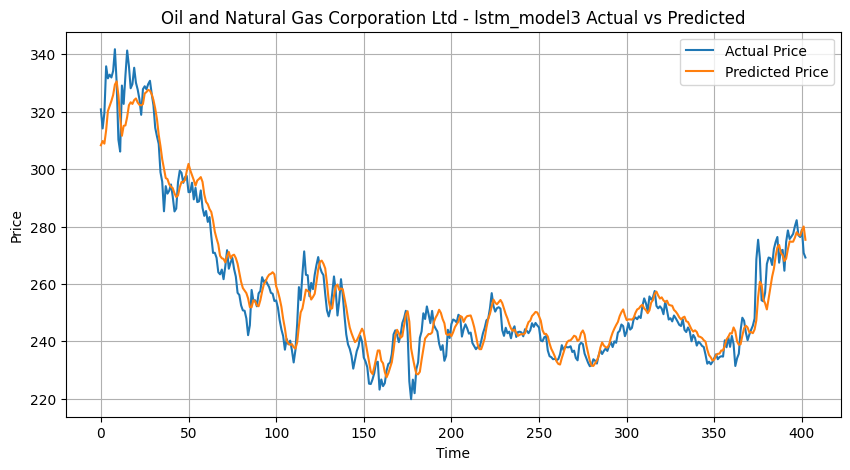

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/Oil_and_Natural_Gas_Corporation_Ltd_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


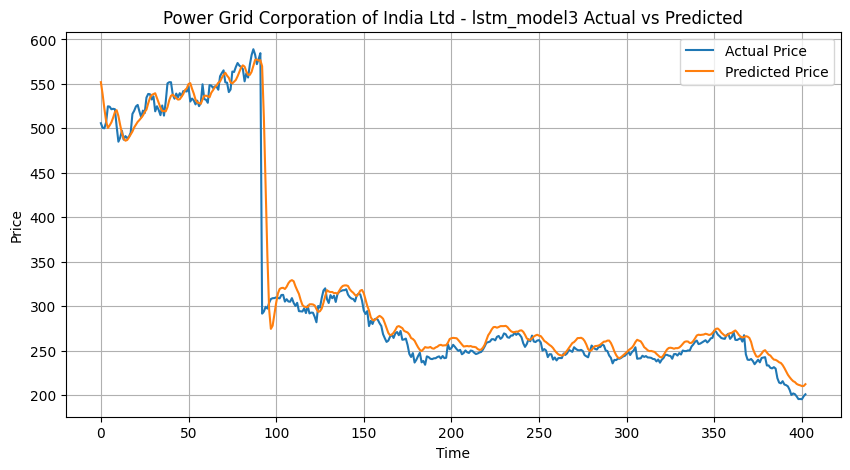

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/Power_Grid_Corporation_of_India_Ltd_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


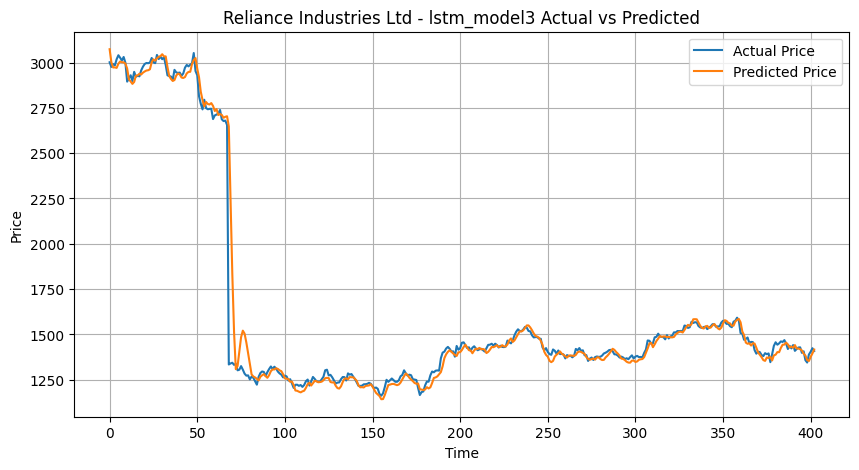

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/Reliance_Industries_Ltd_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


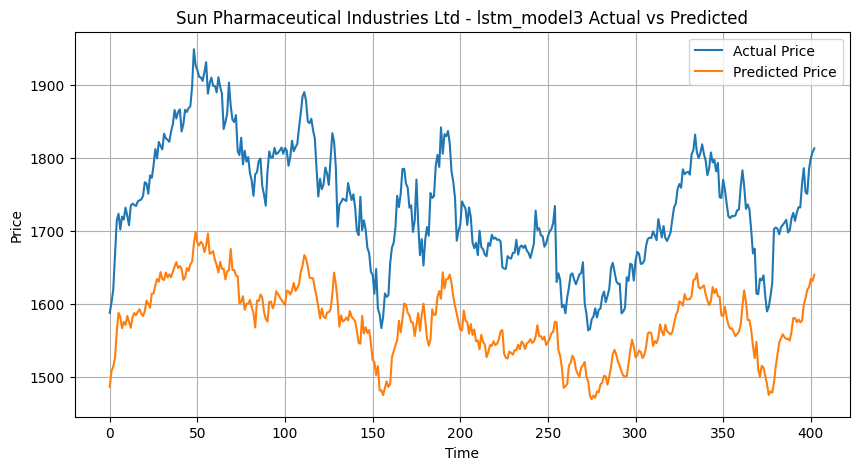

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/Sun_Pharmaceutical_Industries_Ltd_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


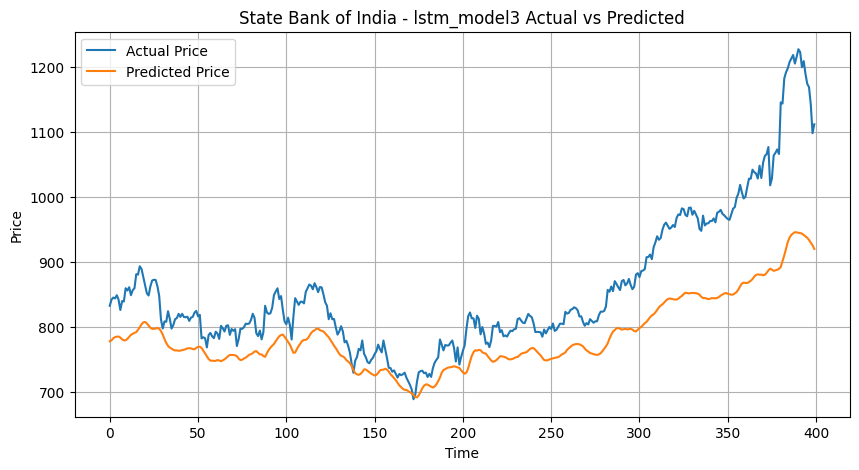

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/State_Bank_of_India_lstm_model3_actual_vs_pred.png
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


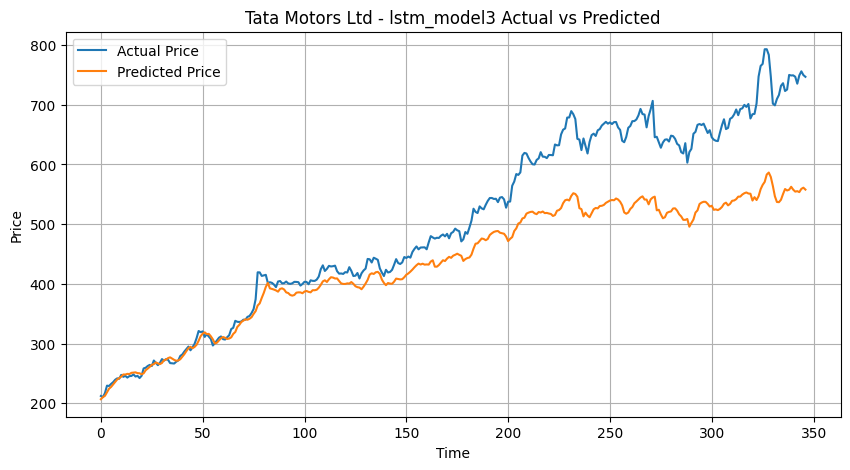

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/Tata_Motors_Ltd_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


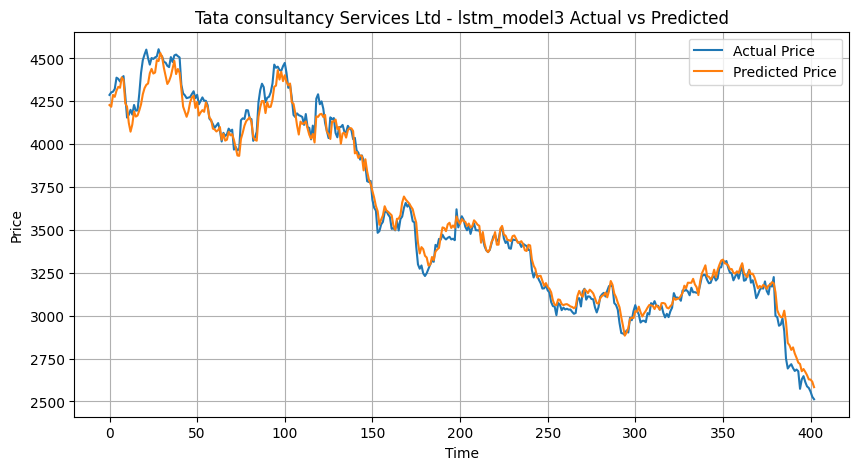

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/Tata_consultancy_Services_Ltd_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


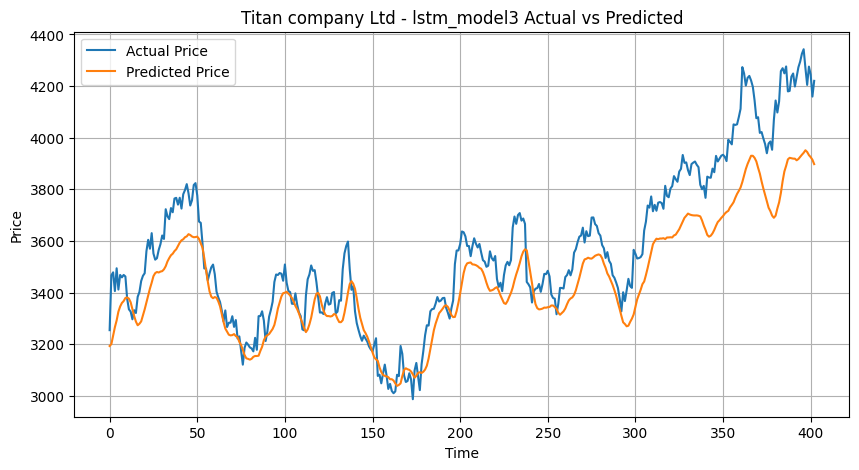

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/Titan_company_Ltd_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


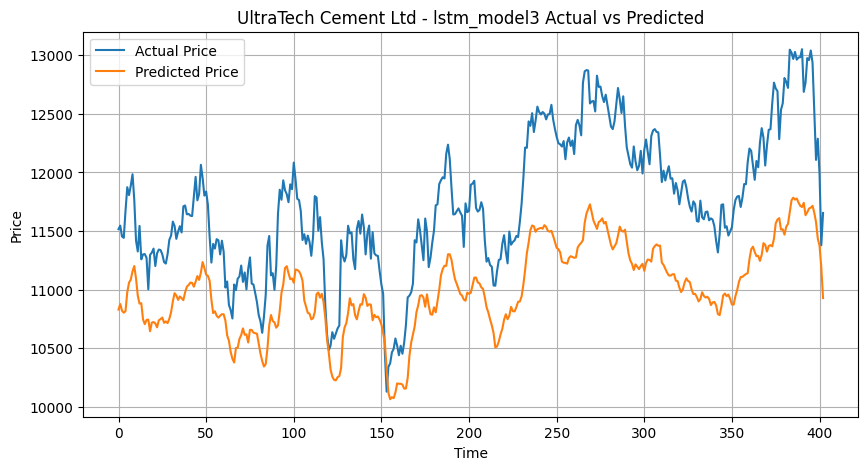

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/UltraTech_Cement_Ltd_lstm_model3_actual_vs_pred.png
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


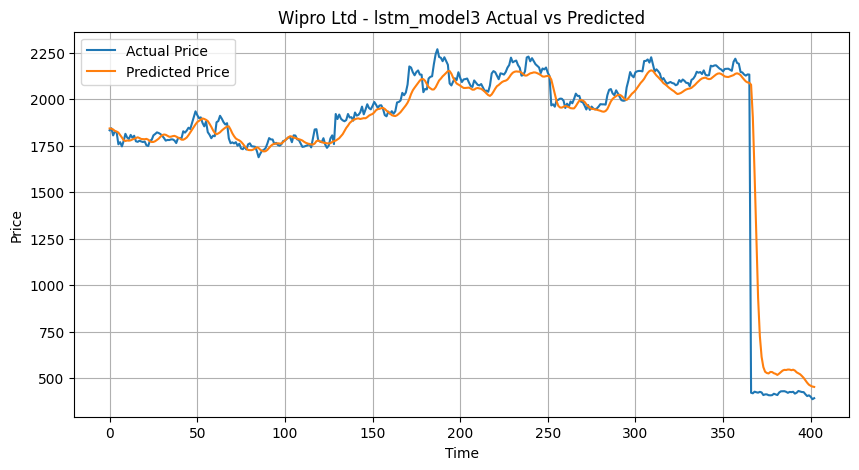

Plot saved at: /content/drive/MyDrive/major_data/LSTM_3/lstm3_plots/Wipro_Ltd_lstm_model3_actual_vs_pred.png


In [13]:
for company, data in all_lstm_models.items():

    model = data['model3']
    X_test = data['X_test']
    y_test = data['y_test']
    scaler = data['target_scaler']

    # Predict
    y_pred = model.predict(X_test)

    # Inverse scale
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    y_pred_inv = scaler.inverse_transform(y_pred)

    # Plot
    plt.figure(figsize=(10,5))
    plt.plot(y_test_inv, label="Actual Price")
    plt.plot(y_pred_inv, label="Predicted Price")
    plt.title(f"{company} - {MODEL_TAG} Actual vs Predicted")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)

    # Save plot
    safe_name = company.replace(" ", "_").replace(".", "")
    plot_path = os.path.join(PLOT_DIR3, f"{safe_name}_{MODEL_TAG}_actual_vs_pred.png")
    plt.savefig(plot_path)
    plt.show()

    print(f"Plot saved at: {plot_path}")

In [14]:
# PREDICTION
from datetime import timedelta

def predict_future_lstm_model3(company, all_lstm_models, processed_data, n_future=5):

    data = all_lstm_models[company]

    model = data['model3']
    feature_scaler = data['feature_scaler']
    target_scaler  = data['target_scaler']
    timesteps      = data['timesteps']
    feature_columns = data['feature_columns']

    #  IMPORTANT → recreate engineered features
    df = processed_data[company].copy()
    df_feat = create_features(df)

    scaled_features = feature_scaler.transform(df_feat[feature_columns])
    current_seq = scaled_features[-timesteps:]

    future_preds = []

    for _ in range(n_future):

        X_input = np.expand_dims(current_seq, axis=0)
        pred_scaled = model.predict(X_input, verbose=0)[0][0]

        pred_real = target_scaler.inverse_transform([[pred_scaled]])[0][0]
        future_preds.append(pred_real)

        # Update sequence
        next_row = current_seq[-1].copy()

        if 'Close' in feature_columns:
            next_row[feature_columns.index('Close')] = pred_scaled

        current_seq = np.vstack([current_seq[1:], next_row])

    future_dates = [
        df_feat['Date'].iloc[-1] + timedelta(days=i+1)
        for i in range(n_future)
    ]

    return pd.DataFrame({
        'Date': future_dates,
        'Predicted_Close': future_preds
    }).set_index('Date')


In [15]:
all_lstm_predictions_model3 = {}

for company in all_lstm_models.keys():

    pred_df = predict_future_lstm_model3(
        company=company,
        all_lstm_models=all_lstm_models,
        processed_data=processed_data,
        n_future=5
    )

    all_lstm_predictions_model3[company] = pred_df

    print(f" Future prediction (Model3) done for {company}")


 Future prediction (Model3) done for Adani Enterprises Ltd
 Future prediction (Model3) done for Adani ports and special Economic
 Future prediction (Model3) done for Bajaj Finance Ltd
 Future prediction (Model3) done for Axis Bank Ltd
 Future prediction (Model3) done for Bajaj Finserv Ltd
 Future prediction (Model3) done for Bharat Electronics Ltd
 Future prediction (Model3) done for Bharti Airtel Ltd
 Future prediction (Model3) done for Eternal Ltd
 Future prediction (Model3) done for HCL Technologies Ltd
 Future prediction (Model3) done for HDFC Bank Ltd
 Future prediction (Model3) done for Hindustan Unilever Ltd
 Future prediction (Model3) done for ICICI Bank Ltd
 Future prediction (Model3) done for ITC Ltd
 Future prediction (Model3) done for Infosys Ltd
 Future prediction (Model3) done for JSW Steel Ltd
 Future prediction (Model3) done for Larsen and Toubro Ltd
 Future prediction (Model3) done for Kotak Mahindra Bank Ltd
 Future prediction (Model3) done for Mahindra and Mahindra L

In [16]:
from datetime import timedelta
import numpy as np
import pandas as pd

n_future = 5
all_predictions_model3 = {}

for company, data in all_lstm_models.items():

    model = data['model3']          # Model3 key
    feature_scaler = data['feature_scaler']
    target_scaler = data['target_scaler']
    timesteps = data['timesteps']
    feature_columns = data['feature_columns']   # IMPORTANT

    #  Recreate engineered features (Model3 needs this)
    df = processed_data[company].copy()
    df_feat = create_features(df)

    scaled_features = feature_scaler.transform(df_feat[feature_columns])
    current_seq = scaled_features[-timesteps:]

    future_preds = []

    for _ in range(n_future):

        X_input = np.expand_dims(current_seq, axis=0)
        pred_scaled = model.predict(X_input, verbose=0)[0][0]

        pred_real = target_scaler.inverse_transform([[pred_scaled]])[0][0]
        future_preds.append(pred_real)

        # Update sequence
        next_row = current_seq[-1].copy()

        if 'Close' in feature_columns:
            close_index = feature_columns.index('Close')
            next_row[close_index] = pred_scaled

        current_seq = np.vstack([current_seq[1:], next_row])

    last_date = df_feat['Date'].iloc[-1]
    future_dates = [last_date + timedelta(days=i+1) for i in range(n_future)]

    pred_df = pd.DataFrame({
        'Date': future_dates,
        'Predicted_Close': future_preds
    }).set_index('Date')

    all_predictions_model3[company] = pred_df

    print(f"{company} next {n_future} days predicted (Model3)")


Adani Enterprises Ltd next 5 days predicted (Model3)
Adani ports and special Economic next 5 days predicted (Model3)
Bajaj Finance Ltd next 5 days predicted (Model3)
Axis Bank Ltd next 5 days predicted (Model3)
Bajaj Finserv Ltd next 5 days predicted (Model3)
Bharat Electronics Ltd next 5 days predicted (Model3)
Bharti Airtel Ltd next 5 days predicted (Model3)
Eternal Ltd next 5 days predicted (Model3)
HCL Technologies Ltd next 5 days predicted (Model3)
HDFC Bank Ltd next 5 days predicted (Model3)
Hindustan Unilever Ltd next 5 days predicted (Model3)
ICICI Bank Ltd next 5 days predicted (Model3)
ITC Ltd next 5 days predicted (Model3)
Infosys Ltd next 5 days predicted (Model3)
JSW Steel Ltd next 5 days predicted (Model3)
Larsen and Toubro Ltd next 5 days predicted (Model3)
Kotak Mahindra Bank Ltd next 5 days predicted (Model3)
Mahindra and Mahindra Ltd next 5 days predicted (Model3)
Maruti Suzuki India Ltd next 5 days predicted (Model3)
NTPC Ltd next 5 days predicted (Model3)
Oil and Na

In [17]:
for company, pred in all_predictions_model3.items():
    print(company)
    print(pred)
    print("-" * 40)

Adani Enterprises Ltd
            Predicted_Close
Date                       
2026-03-11      2027.824266
2026-03-12      2005.053629
2026-03-13      1992.451663
2026-03-14      1988.184391
2026-03-15      1987.858060
----------------------------------------
Adani ports and special Economic
            Predicted_Close
Date                       
2026-03-11       431.875877
2026-03-12       429.000663
2026-03-13       426.914845
2026-03-14       425.891091
2026-03-15       425.973414
----------------------------------------
Bajaj Finance Ltd
            Predicted_Close
Date                       
2026-03-11       843.653613
2026-03-12       822.893937
2026-03-13       807.858554
2026-03-14       797.704865
2026-03-15       793.461473
----------------------------------------
Axis Bank Ltd
            Predicted_Close
Date                       
2026-03-11      1186.062719
2026-03-12      1178.097009
2026-03-13      1170.341850
2026-03-14      1163.964905
2026-03-15      1158.436876
------

In [18]:
import os
import shutil
import pandas as pd

# Convert dictionary of predictions to a single DataFrame
final_pred_df = pd.concat(all_predictions_model3, axis=1)
final_pred_df.columns = [col[0] for col in final_pred_df.columns]  # clean column labels
final_pred_df.index.name = 'Date'

# Main output file (MODEL 3)
output_path = "/content/drive/MyDrive/major_data/Future/LSTM_3/model3_future_predictions.csv"

# Ensure parent folder exists
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# If a directory accidentally exists with same name → remove it
if os.path.isdir(output_path):
    shutil.rmtree(output_path)

# Save combined predictions
final_pred_df.to_csv(output_path)

# Save individual company predictions
individual_folder = "/content/drive/MyDrive/major_data/Future/LSTM_3/model3_individual_predictions"
os.makedirs(individual_folder, exist_ok=True)

for company in final_pred_df.columns:
    company_safe = company.replace(" ", "_")

    company_df = final_pred_df[[company]]  # select single column

    company_df.to_csv(
        os.path.join(individual_folder, f"{company_safe}_future.csv")
    )

print(f"Combined file saved: {output_path}")
print(f"Individual company files saved in: {individual_folder}")

Combined file saved: /content/drive/MyDrive/major_data/Future/LSTM_3/model3_future_predictions.csv
Individual company files saved in: /content/drive/MyDrive/major_data/Future/LSTM_3/model3_individual_predictions


In [19]:
# RECOMMENDATION / RANKING
def expected_return(last_price, future_price):
    return ((future_price - last_price) / last_price) * 100

In [20]:
lstm_ranking_model3 = []

for company in all_lstm_models.keys():

    pred_df = predict_future_lstm_model3(
        company,
        all_lstm_models,
        processed_data,
        n_future=5
    )

    last_close = processed_data[company]['Close'].iloc[-1]
    future_close = pred_df['Predicted_Close'].iloc[-1]

    ret = expected_return(last_close, future_close)

    lstm_ranking_model3.append({
        'Company': company,
        'Last_Close': round(last_close, 2),
        'Predicted_Close_5D': round(future_close, 2),
        'Expected_Return_%': round(ret, 2)
    })

ranking_df_model3 = pd.DataFrame(lstm_ranking_model3)
ranking_df_model3 = ranking_df_model3.sort_values(by='Expected_Return_%', ascending=False)
ranking_df_model3 = ranking_df_model3.reset_index(drop=True)

ranking_df_model3.insert(0, 'Rank', range(1, len(ranking_df_model3) + 1))

top10_lstm3 = ranking_df_model3.head(10)

top10_lstm3

,Rank,Company,Last_Close,Predicted_Close_5D,Expected_Return_%
0,1,Wipro Ltd,383.20,462.84,20.78
1,2,Bajaj Finserv Ltd,1795.30,2006.82,11.78
2,3,Power Grid Corporation of India Ltd,202.23,216.72,7.16
3,4,HDFC Bank Ltd,833.95,864.00,3.60
4,5,Larsen and Toubro Ltd,309.00,315.41,2.07
5,6,Tata consultancy Services Ltd,2464.90,2515.59,2.06
6,7,Adani Enterprises Ltd,1974.70,1987.86,0.67
7,8,Eternal Ltd,1178.80,1186.31,0.64
8,9,Oil and Natural Gas Corporation Ltd,270.75,272.16,0.52
9,10,Bharat Electronics Ltd,223.80,224.48,0.31


In [21]:
import os

# Path to existing folder
LSTM_RANKING_DIR = "/content/drive/MyDrive/major_data/Ranking"

# Create DataFrame from Model 3 ranking
ranking_df_model3 = pd.DataFrame(lstm_ranking_model3)

# Sort by Expected Return
ranking_df_model3 = ranking_df_model3.sort_values(
    by='Expected_Return_%',
    ascending=False
).reset_index(drop=True)

# Save file
file_path = os.path.join(LSTM_RANKING_DIR, "LSTM_3_top_ranking.csv")

ranking_df_model3.to_csv(file_path, index=False)

print(f"Model 3 Ranking saved successfully at:\n{file_path}")

Model 3 Ranking saved successfully at:
/content/drive/MyDrive/major_data/Ranking/LSTM_3_top_ranking.csv


In [22]:
import os
import pandas as pd

# Create folder for saving Model3 test results
PRED_RESULTS_DIR3 = "/content/drive/MyDrive/major_data/LSTM_3/lstm3_predicted_prices"
os.makedirs(PRED_RESULTS_DIR3, exist_ok=True)

# Save predicted vs actual for each company (test set)
for company, data in all_lstm_models.items():

    X_test = data['X_test']
    y_test = data['y_test']
    scaler = data['target_scaler']

    # model3
    y_pred_scaled = data['model3'].predict(X_test)

    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_true = scaler.inverse_transform(y_test)

    test_df = pd.DataFrame({
        'Actual_Close': y_true.flatten(),
        'Predicted_Close': y_pred.flatten()
    })

    file_path = os.path.join(
        PRED_RESULTS_DIR3,
        f"{company.replace(' ', '_')}_test_results.csv"
    )

    test_df.to_csv(file_path, index=False)

    print(f"Test results saved for {company} (Model3)")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Test results saved for Adani Enterprises Ltd (Model3)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Test results saved for Adani ports and special Economic (Model3)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Test results saved for Bajaj Finance Ltd (Model3)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Test results saved for Axis Bank Ltd (Model3)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Test results saved for Bajaj Finserv Ltd (Model3)
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Test results saved for Bharat Electronics Ltd (Model3)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Test results saved for Bharti Airtel Ltd (Model3)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Test results saved for Eternal Ltd (Model3)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Test results saved for HCL Technologies Ltd (Model3)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Test results saved for HDFC Bank Ltd (Model3)
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Test results saved for Hindustan Unilever Ltd (Model

In [23]:
import os
import json
import joblib
from tensorflow.keras.models import load_model

LSTM3_DIR = "/content/drive/MyDrive/major_data/LSTM_3/lstm_saved_model3"

lstm3_models = {}

for company_folder in os.listdir(LSTM3_DIR):

    company_path = os.path.join(LSTM3_DIR, company_folder)

    if os.path.isdir(company_path):

        company_name = company_folder.replace("_", " ")

        # Load model
        model = load_model(os.path.join(company_path, "lstm_model3.keras"))

        # Load scalers
        feature_scaler = joblib.load(
            os.path.join(company_path, "feature_scaler.pkl")
        )

        target_scaler = joblib.load(
            os.path.join(company_path, "target_scaler.pkl")
        )

        # Load metadata
        with open(os.path.join(company_path, "metadata.json"), "r") as f:
            metadata = json.load(f)

        lstm3_models[company_name] = {
            "model": model,
            "feature_scaler": feature_scaler,
            "target_scaler": target_scaler,
            "timesteps": metadata["timesteps"],
            "feature_columns": metadata["feature_columns"]
        }

        print(f" Loaded LSTM Model3 for {company_name}")

print("\n All LSTM Model3 loaded successfully!")

 Loaded LSTM Model3 for Adani Enterprises Ltd
 Loaded LSTM Model3 for Adani ports and special Economic
 Loaded LSTM Model3 for Bajaj Finance Ltd
 Loaded LSTM Model3 for Axis Bank Ltd
 Loaded LSTM Model3 for Bajaj Finserv Ltd
 Loaded LSTM Model3 for Bharat Electronics Ltd
 Loaded LSTM Model3 for Bharti Airtel Ltd
 Loaded LSTM Model3 for Eternal Ltd
 Loaded LSTM Model3 for HCL Technologies Ltd
 Loaded LSTM Model3 for HDFC Bank Ltd
 Loaded LSTM Model3 for Hindustan Unilever Ltd
 Loaded LSTM Model3 for ICICI Bank Ltd
 Loaded LSTM Model3 for ITC Ltd
 Loaded LSTM Model3 for Infosys Ltd
 Loaded LSTM Model3 for JSW Steel Ltd
 Loaded LSTM Model3 for Larsen and Toubro Ltd
 Loaded LSTM Model3 for Kotak Mahindra Bank Ltd
 Loaded LSTM Model3 for Mahindra and Mahindra Ltd
 Loaded LSTM Model3 for Maruti Suzuki India Ltd
 Loaded LSTM Model3 for NTPC Ltd
 Loaded LSTM Model3 for Oil and Natural Gas Corporation Ltd
 Loaded LSTM Model3 for Power Grid Corporation of India Ltd
 Loaded LSTM Model3 for Relian